<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan4/blob/main/PCD_Pratikum_2_Latihan_1_Pertemuan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload gambar grayscale atau gambar biasa


Saving Foto Tugas Citra Digital.jpeg to Foto Tugas Citra Digital.jpeg


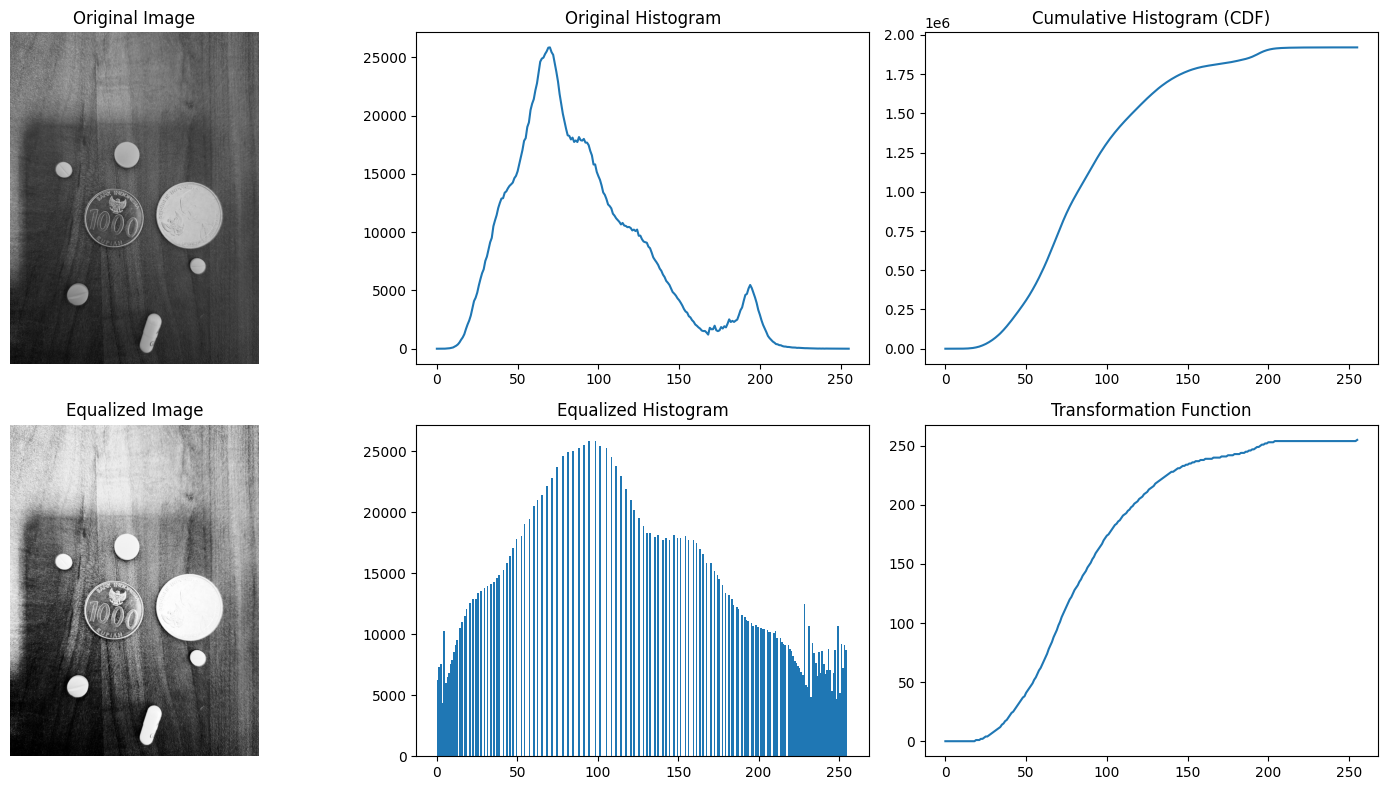

In [ ]:
# =========================================================
# PRAKTIKUM: MANUAL HISTOGRAM EQUALIZATION
# Google Colab Ready
# =========================================================

# 1. Import Library
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# =========================================================
# Upload Gambar
# =========================================================
print("Upload gambar grayscale atau gambar biasa")
uploaded = files.upload()

# Ambil nama file
filename = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# =========================================================
# Fungsi Manual Histogram Equalization
# =========================================================
def manual_histogram_equalization(image):
    """
    Manual implementation of histogram equalization

    Parameters:
    image : Input grayscale image (0-255)

    Returns:
    equalized_image : hasil citra setelah equalization
    transform : fungsi transformasi
    histogram : histogram asli
    cdf : cumulative histogram
    """

    # 1. Hitung histogram
    histogram = np.zeros(256)

    for pixel in image.flatten():
        histogram[pixel] += 1

    # 2. Hitung cumulative histogram (CDF)
    cdf = histogram.cumsum()

    # Normalisasi CDF
    cdf_normalized = cdf / cdf.max()

    # 3. Hitung transformation function
    transform = np.floor(255 * cdf_normalized).astype(np.uint8)

    # 4. Apply transformation
    equalized_image = transform[image]

    # 5. Return hasil
    return equalized_image, transform, histogram, cdf


# =========================================================
# Jalankan Histogram Equalization
# =========================================================
equalized_image, transform, histogram, cdf = manual_histogram_equalization(image)

# =========================================================
# Visualisasi Hasil
# =========================================================
plt.figure(figsize=(15,8))

# Citra Asli
plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Histogram Asli
plt.subplot(2,3,2)
plt.plot(histogram)
plt.title("Original Histogram")

# CDF
plt.subplot(2,3,3)
plt.plot(cdf)
plt.title("Cumulative Histogram (CDF)")

# Citra Setelah Equalization
plt.subplot(2,3,4)
plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

# Histogram Setelah Equalization
plt.subplot(2,3,5)
plt.hist(equalized_image.flatten(), bins=256, range=[0,256])
plt.title("Equalized Histogram")

# Transformation Function
plt.subplot(2,3,6)
plt.plot(transform)
plt.title("Transformation Function")

plt.tight_layout()
plt.show()